In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image
from scipy.integrate import trapezoid
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve


# -------------- Auxiliar 4 --------------

## AS4501-1 

<font size='3'> Profs. Valentino Gonzalez, Francisco Förster

<font size='3'> Author: P. Cáceres Burgos

# ------------------------------------------

# Classification

<font size='3'> In this class we will be classifiers !!! We will look at different RGB images from SDSS DR16 sources and classify whether they are Stars or Quasars (QSO). 
    
<font size='3'> Quasars were first discovered in the 1950s, and were categorized as "Quasi-stellar objects" due to their point-like emission, similar to stars. Quasars are a sub-category from Active Galactic Nuclei (AGNs) that are characterized by being very luminous (Lbol>1e45 erg/s), found at high-zs (z>0.2) and with an emission that outshines its host galaxy. 
    
<font size='3'> The dataset we will work with comes selecting 15 sources from the Sloan Digital Sky Survey Quasar Catalog: sixteenth data release (DR16Q) (https://www.sdss4.org/dr17/algorithms/qso_catalog/) and 15 sources from the Gaia Archive (https://gea.esac.esa.int/archive/) 
    


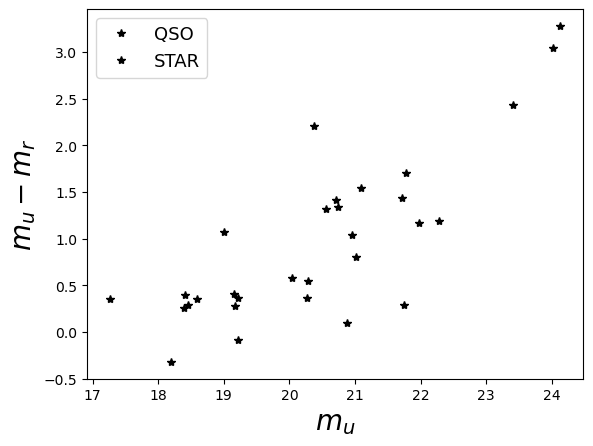

In [9]:
# the dataset: 

dataset = pd.read_csv('../Data_AUXs/STAR_QSO_info.txt')
dataset = dataset#.iloc#[:-2] #[['name', 'ra', 'dec', 'umag', 'rmag']]
labels = ["QSO", "STAR"]


qso_data = dataset[dataset['type']=='QSO']
star_data = dataset[dataset['type']=='STAR']
plt.plot(qso_data.umag, qso_data.umag - qso_data.rmag, '*', color='k', label='QSO')
plt.plot(star_data.umag, star_data.umag - star_data.rmag, '*', color='k',label='STAR')
plt.xlabel('$m_u$', fontsize=20)
plt.ylabel('$m_u - m_r$', fontsize=20)
plt.legend(frameon='False', fontsize=13)

# Let's take a guess...

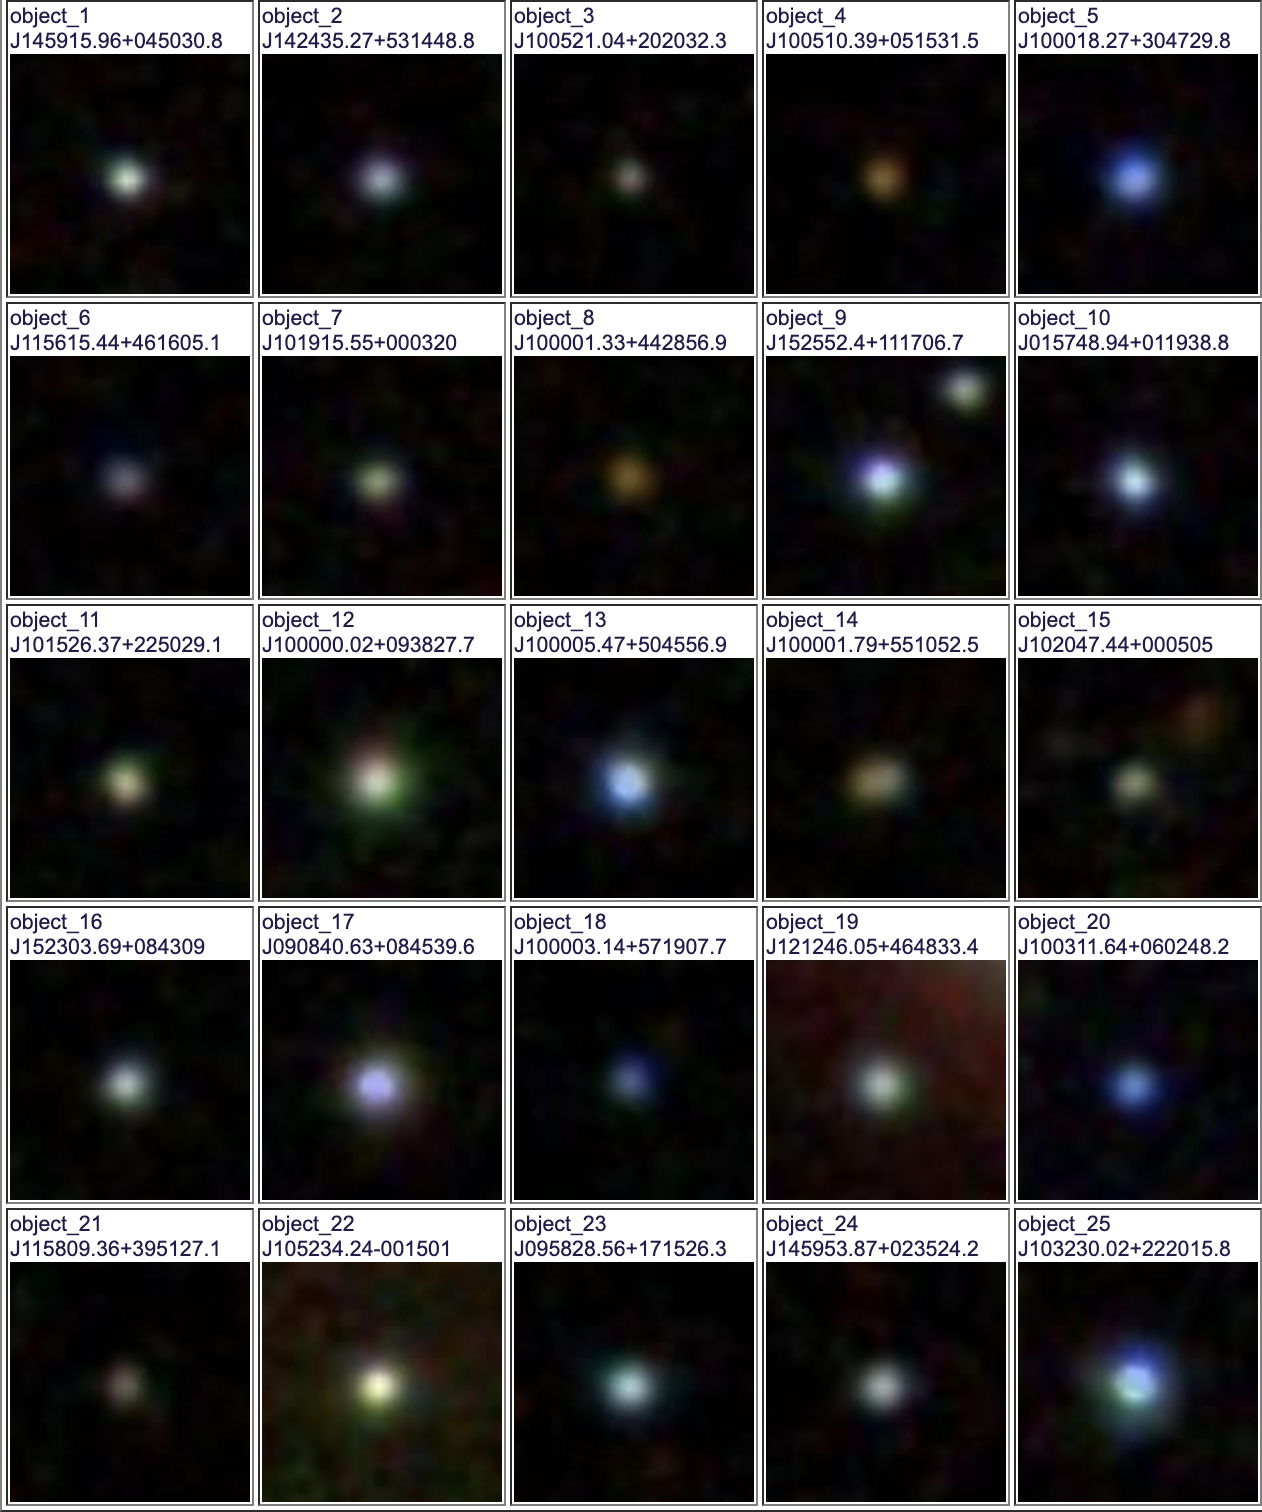

In [49]:
Image(data='../Data_AUXs/sources_imag1.png')

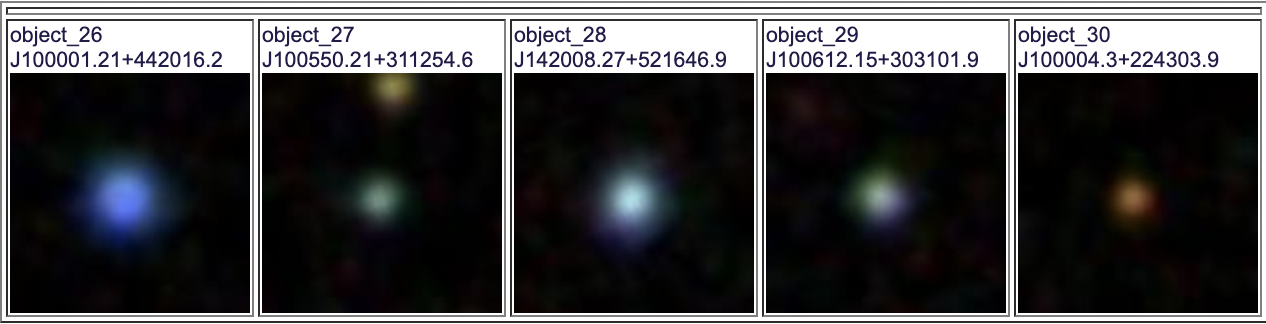

In [50]:
Image(data='../Data_AUXs/sources_imag2.png')

In [47]:
#tags = ['Star',
#       'QSO',
#       'Star',
#       ....]
#


tags = np.array(['STAR', 'QSO', 'QSO', 'QSO', 'QSO', 'QSO', 'QSO', 'STAR', 'QSO',
       'STAR', 'STAR', 'QSO', 'QSO', 'STAR', 'STAR', 'STAR', 'QSO',
       'QSO', 'STAR', 'QSO', 'QSO', 'QSO', 'QSO', 'STAR', 'QSO', 'QSO',
       'STAR', 'STAR','STAR', 'STAR'])
#np.random.shuffle(tags)
#
#y_score = m,.
#random.random(size=len(dataset))
#


y_pred = ['STAR','QSO','STAR','STAR','QSO','STAR','STAR','STAR','QSO','QSO','STAR','QSO','QSO','QSO','STAR','STAR','QSO','STAR','QSO','STAR','STAR','QSO','QSO','STAR','QSO','STAR', 'STAR','QSO','QSO','STAR']
y_score = np.array([2,5,1,1,5,3,0,1,5,7,3,7,6,4,1,3,7,1,6,0,1,7,5,0,7,3,1,7,7,1])/7

dataset['predicted_type'] = y_pred #tags


In [48]:
len(y_score)

30

## Now, we can calculate all the metrics from our predictions!
 

<font size='3'> We can use the Sklearn to plot the confusion matrix for the classifier:
    

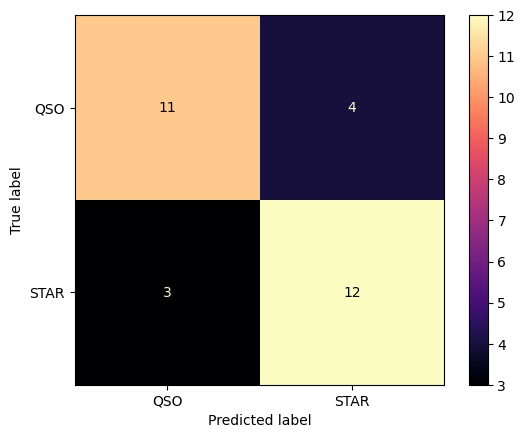

In [49]:
y_true = np.array(dataset.type)
y_pred = np.array(dataset.predicted_type)

cm = confusion_matrix(y_true, y_pred, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=labels)
disp.plot(cmap='magma')

$\Large \rm accuracy = \frac{\#\ correct\ labels}{total}$ 


In [50]:
total = len(dataset)
correct_label = sum(dataset.predicted_type == dataset.type)

A = correct_label/total
A

0.7666666666666667


<font size='3'> Classification Risk $R(f)$

<font size='3'> Expected loss over the joint distribution of inputs x and labels y

$R(f) = E[L(y,\hat{y})]$

<font size='3'> where $\hat{y}$ is the classifier, y are the true labels, $L(y,\hat{y})$ is the loss function and $E$ is the expectation over the data distribution. A simple loss function can be 
   
$L(y, \hat{y}) = 
\begin{cases}
0 & \text{if } \hat{y} = y \\
1 & \text{if } \hat{y} \ne y
\end{cases}$
    
or $\Large \rm accuracy = 1 - R(f)$
or $\Large \rm R(f) = 1 - Accuracy$
    

    

In [51]:
R = 1 - A
R

0.23333333333333328

<font size='3'> Next comes calculating the completeness, contamination, recall and precision. 

<font size='3'> **Recall** and **Completness** is the ability of the classifier to find all the positive samples. The best value is 1 and the worst value is 0.

<font size='3'> **Precision** is intuitively the ability of the classifier not to label as positive a sample that is negative. The best value is 1 and the worst value is 0.

<font size='3'> **Contamination**, in contrast to precision, tells us how wrongly is the classifier labeling the sample. The best value is 0, and the worst is 1.

$\Large \rm recall = \rm completeness\ =\ \frac{true~ positives}{true~ positives~ +~ false~ negatives}$

$\Large 1 - \rm precision = \rm contamination\ =\ \frac{false~ positives}{true~ positives~ +~ false~ positives}$

<font size='3'> Since this is a binary classifier, we will consider "true" to be Quasar, and "false" to be the star category. 

In [52]:
FP = 0 
FN = 0 
TP = 0 
TN = 0 

for ypred, yreal in zip(y_pred, y_true):
    
    if ypred == 'QSO' and yreal=='QSO':
        TP+=1
    elif ypred == 'QSO' and yreal=='STAR':
        FP+=1
    elif ypred == 'STAR' and yreal=='STAR':
        TN+=1
    elif ypred == 'STAR' and yreal =='QSO':
        FN+=1

In [53]:
print('False positive: {}, False negative: {}, True positive: {}, True negative: {}'.format(FP, FN, TP, TN))

print(' \n These numbers should be equal to the confusion matrix values from above: \n')

print('False positive: {}, False negative: {}, True positive: {}, True negative: {}'.format(cm[1,0], cm[0,1], cm[0,0], cm[1,1]))


False positive: 3, False negative: 4, True positive: 11, True negative: 12
 
 These numbers should be equal to the confusion matrix values from above: 

False positive: 3, False negative: 4, True positive: 11, True negative: 12


In [54]:
Completeness = TP / (TP + FN)
Recall = Completeness
Contamination = FP / (TP + FP)
Precision = 1 - Contamination

print('Recall = Completeness = ', Completeness)
print('Contamination = ',Contamination)
print('Precision = ', 1 - Contamination)

Recall = Completeness =  0.7333333333333333
Contamination =  0.21428571428571427
Precision =  0.7857142857142857


<font size='3'>  The $F_1$ score can be interpreted as a harmonic mean of the precision and recall, it reaches its best value at 1 and worst score at 0

$\Large \rm F_1 = 2\ \frac{1}{\frac{1}{precision}\ +\ \frac{1}{recall}} = 2\ \frac{precision\ \times\ recall}{precision\ +\ recall}$

In [55]:
F1 = 2 * (Precision * Recall)/(Precision + Recall)
F1

0.7586206896551724

### Receiver operating characteristic (ROC)

<font size='3'> Tells us the performance of a binary classifier at varying threshold values. It calculates the True positive rate (TPR) and the False positive rate (FPR) at different thresholds. 
    
$\large \rm TPR = \rm Recall$ 
    
$\large \rm FPR = \frac{FP}{FP + TN}$

In [56]:
y_true_bin = (y_true == 'QSO').astype(float)
fpr, tpr, thresholds = roc_curve(y_true_bin, y_score)

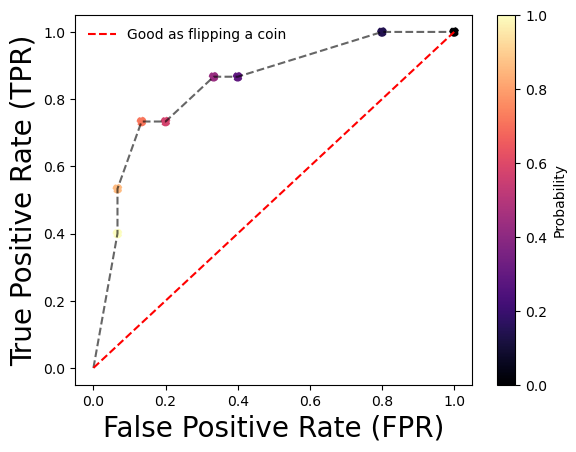

In [57]:
plt.scatter(fpr, tpr, c = thresholds, cmap='magma', ls='--')
plt.plot(fpr, tpr, color='k', ls='--', alpha=0.6)

plt.colorbar(label='Probability')
plt.plot([fpr.min(), fpr.max()], [tpr.min(), tpr.max()], ls='--', color='r', label='Good as flipping a coin')
plt.ylabel('True Positive Rate (TPR)', fontsize=20)
plt.xlabel('False Positive Rate (FPR)', fontsize=20)
plt.legend(frameon=False)


### Area under the curve (AUC) and Gini coefficient (G1)

<font size='3'> The AUC is the probability that the classifier will rank a randomly chosen positive instance higher than a randomly chosen negative one. A perfect classifier has AUC = 1, and a random classifier has AUC = 0.5

<font size='3'> AUC relates the **Gini coefficient**, which is the twice the area between the ROC and the no-discrimination line: 
    
$\Large \rm G_1 = 2 AUC - 1$ 
 
<font size='3'>  The **Gini coefficient** is usually a measure of the distribution of wealth in a country, where G=0 is total equality and G=1 in total inequality). The ROC AUC statistic is normally used to do model comparison.

In [61]:
auc = trapezoid(tpr, fpr)
print('AUC = ', auc)
print('\n')
print('Gini = ', 2 * auc - 1 )

AUC =  0.8422222222222221


Gini =  0.6844444444444442
